<a href="https://colab.research.google.com/github/vyenn/ML2024/blob/main/homework12.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Stanisław Wojciechowski
[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/vyenn/ML2024/blob/main/homework12.ipynb)


## **The Objective**

Your task is to:

1. Construct semantic classes of word pairs.
2. Visualize them using PCA.
3. Explore arithmetic operations in embedding space.

## **Tasks & Deliverables**

### 1. **Semantic Pair Classes**

- You must gather **at least 10 classes** of semantically related word pairs.
- Each class must contain **at least 5 pairs**.
- That gives a **minimum total of 100 unique words** (10 classes x 5 pairs x 2 words per pair).

Two example classes:

**Class 1: Gender**

- (king, queen)
- (man, woman)
- (doctor, nurse)
- (prince, princess)
- *(you must add one more)*

**Class 2: Verb tense (past tense)**

- (bring, brought)
- (get, got)
- (like, liked)
- *(you must add two more)*

**Your job:**

- Invent or search for **at least 10 such classes**, including the examples above.
- Each class must be conceptually coherent.
- Other examples: singular/plural, country/capital, comparative/superlative, tool/user, job/object, etc.

### 2. **Global PCA (Across All Words)**

- Use PCA to reduce the **entire set of 100 word embeddings** to 2D, and plot it.
- Plot the additional **10 separate charts**, one for each class.
  - Each chart should display only the 10 words (5 pairs) of the given class.
- Points should be labeled with the words themselves.

### 3. **Local PCA (Per Class)**

- For each class (10 total), perform PCA **only** on the 10 words of that class.
- Plot these class-wise PCA visualizations as separate charts.
- Again, points should be labeled with the words.

**Total: 21 charts**
(1 global plot with 100 words + 10 global-space class plots + 10 local PCA class plots)

Charts should be presented in a self-explanatory manner with clear labels.

### 4. **Embedding Arithmetic**

For each class, choose **one example pair** (e.g., (king, queen)) and perform the operation:

```
embedding(B) - embedding(A) + embedding(C)
```

Where A and B form a known pair, and C is another base word.
For example:

```
embedding("king") - embedding("man") + embedding("woman")
```

* For each such result vector, find the **5 closest word embeddings** (using cosine similarity or Euclidean distance).
* Print the top 5 neighbors **with their distances**.
* Do this **once per class** (i.e., 10 times).

This will make it possible to verify if
 ```
embedding("queen") ≈ embedding("king") - embedding("man") + embedding("woman")
```
for the *gender*-related class.


### 5. **Discussion**

* Analyze and interpret your 21 plots.
* Discuss whether the vector relationships are preserved.
* Does PCA capture semantic differences?
* Are the closest words from the arithmetic meaningful?
* What kinds of relationships are captured, and what are not?
* Are some classes better behaved than others?


### 6. **Publish on GitHub**  
   - Place the Colab notebook in your **GitHub repository** for this course.
   - In your repository’s **README**, add a **link** to the notebook and also include an **“Open in Colab”** badge at the top of the notebook so it can be launched directly from GitHub.

## **Solution**

<ipython-input-4-e367afda7755>:111: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('tab10', num_classes)


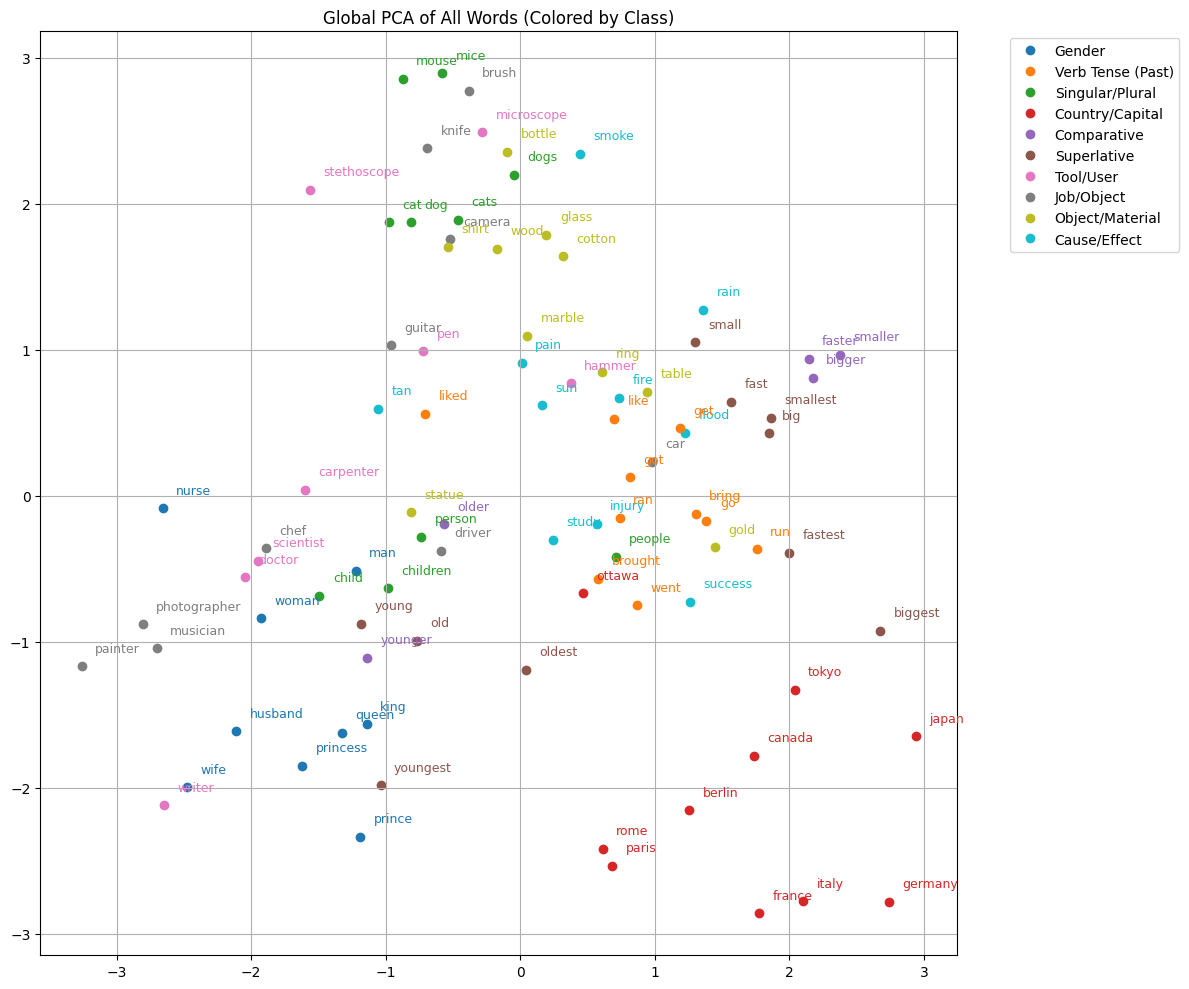

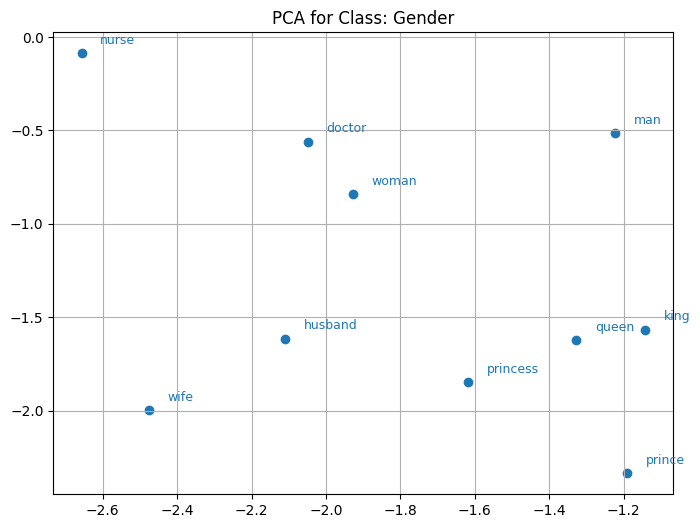

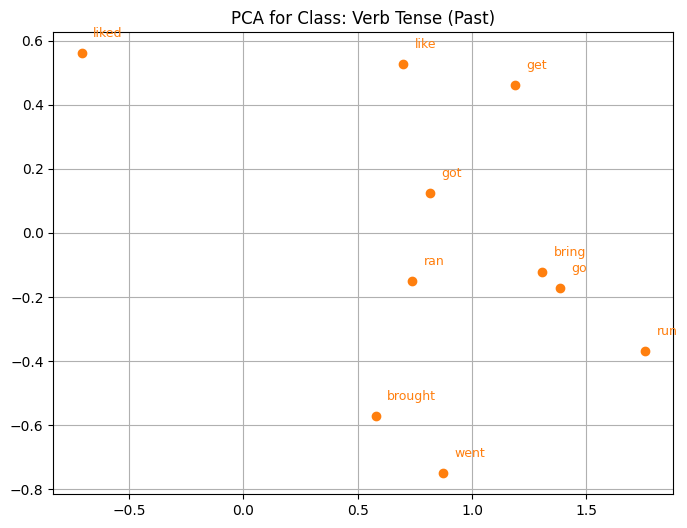

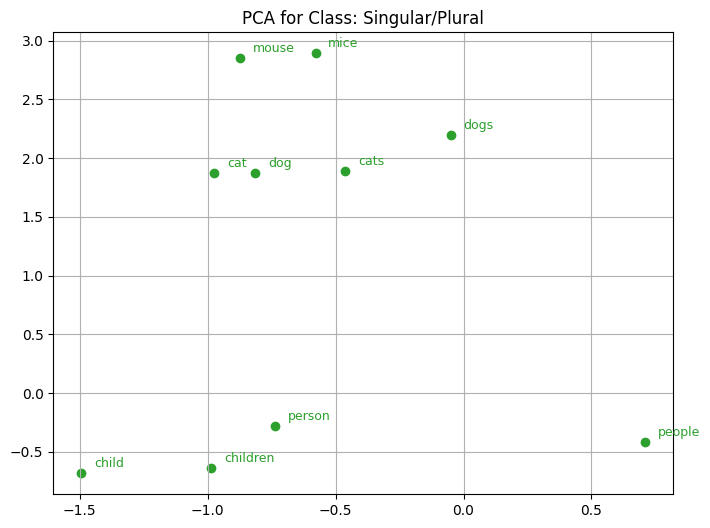

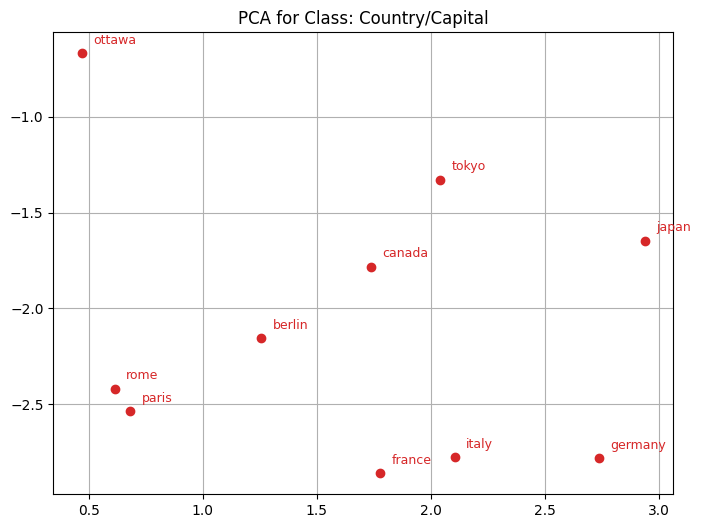

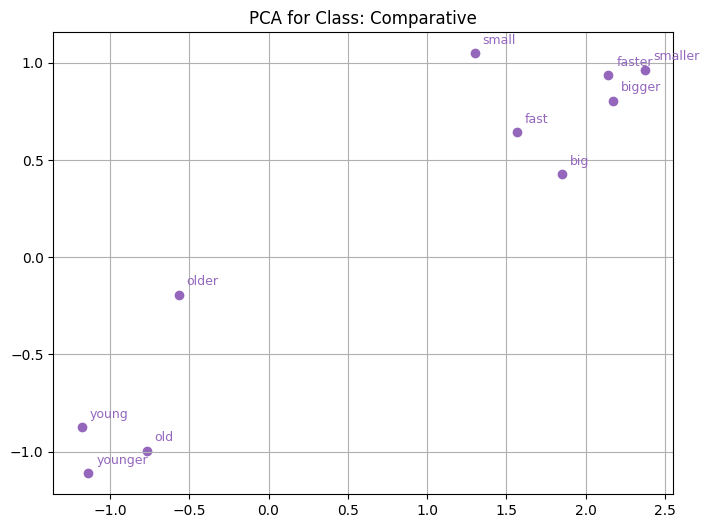

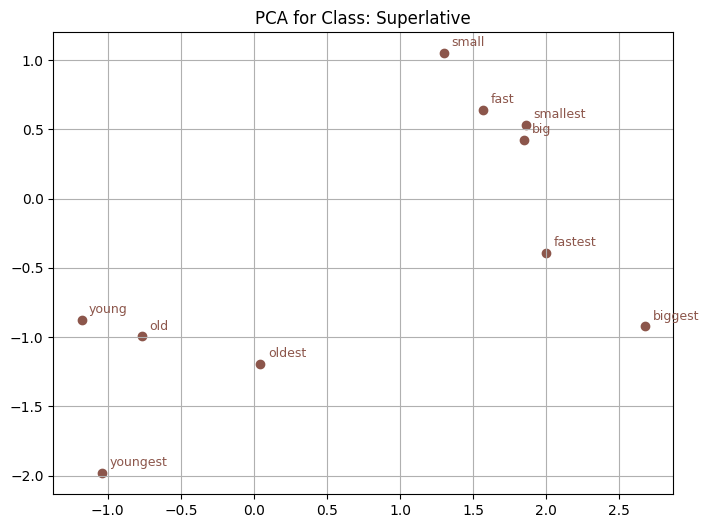

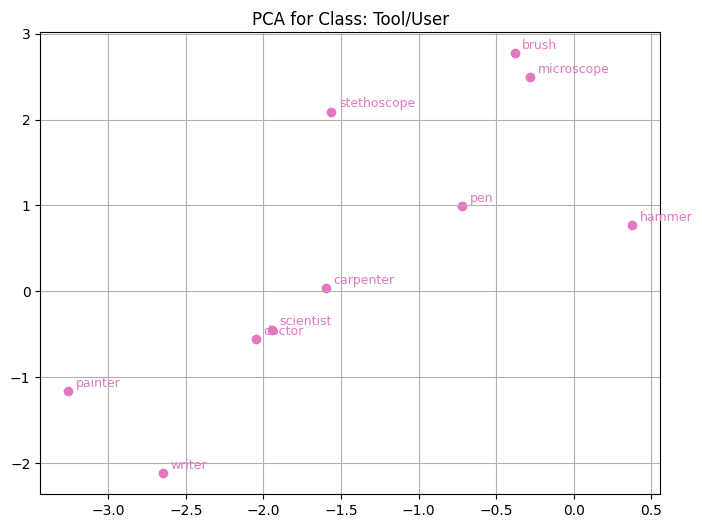

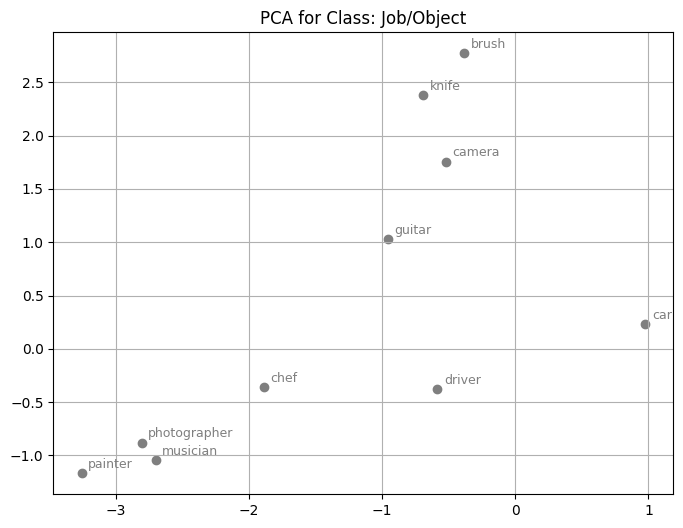

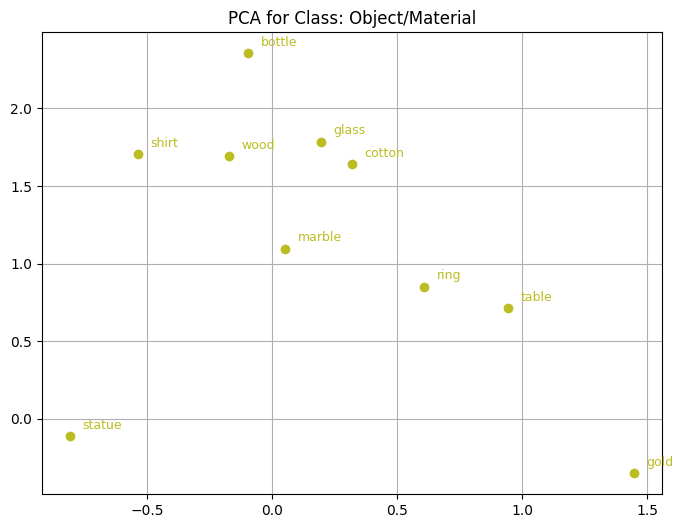

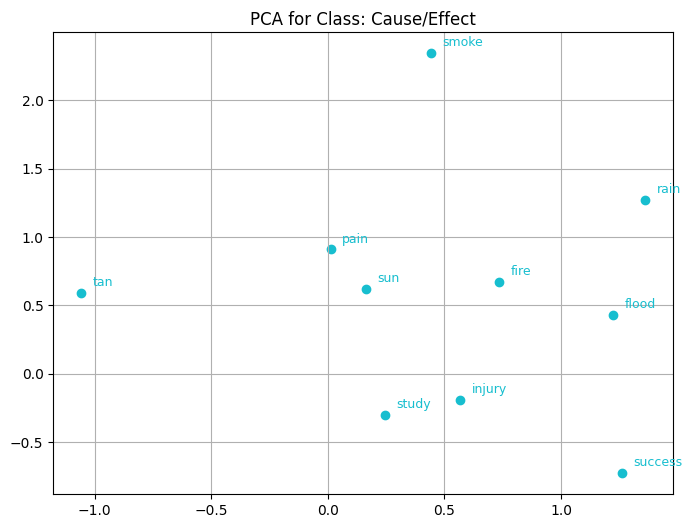

In [4]:
# FIX for gensim / scipy import error
%pip install --quiet gensim==4.3.1 scipy==1.10.1 scikit-learn matplotlib

# Download pretrained embeddings (GloVe Word2Vec format from gensim)
import gensim.downloader as api
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import matplotlib.cm as cm
import numpy as np

# Load a small pretrained word vector model (300d for quality, or 100d for speed)
word_vectors = api.load("glove-wiki-gigaword-100")

# Define semantic classes
semantic_classes = {
    "Gender": [
        ("king", "queen"),
        ("man", "woman"),
        ("doctor", "nurse"),
        ("prince", "princess"),
        ("husband", "wife")
    ],
    "Verb Tense (Past)": [
        ("bring", "brought"),
        ("get", "got"),
        ("like", "liked"),
        ("run", "ran"),
        ("go", "went")
    ],
    "Singular/Plural": [
        ("cat", "cats"),
        ("dog", "dogs"),
        ("child", "children"),
        ("mouse", "mice"),
        ("person", "people")
    ],
    "Country/Capital": [
        ("france", "paris"),
        ("italy", "rome"),
        ("japan", "tokyo"),
        ("germany", "berlin"),
        ("canada", "ottawa")
    ],
    "Comparative": [
        ("big", "bigger"),
        ("small", "smaller"),
        ("fast", "faster"),
        ("old", "older"),
        ("young", "younger")
    ],
    "Superlative": [
        ("big", "biggest"),
        ("small", "smallest"),
        ("fast", "fastest"),
        ("old", "oldest"),
        ("young", "youngest")
    ],
    "Tool/User": [
        ("pen", "writer"),
        ("hammer", "carpenter"),
        ("brush", "painter"),
        ("microscope", "scientist"),
        ("stethoscope", "doctor")
    ],
    "Job/Object": [
        ("chef", "knife"),
        ("driver", "car"),
        ("painter", "brush"),
        ("musician", "guitar"),
        ("photographer", "camera")
    ],
    "Object/Material": [
        ("bottle", "glass"),
        ("table", "wood"),
        ("ring", "gold"),
        ("shirt", "cotton"),
        ("statue", "marble")
    ],
    "Cause/Effect": [
        ("rain", "flood"),
        ("study", "success"),
        ("fire", "smoke"),
        ("sun", "tan"),
        ("injury", "pain")
    ]
}

# Flatten all unique words
unique_words = set()
for pairs in semantic_classes.values():
    for w1, w2 in pairs:
        unique_words.update([w1, w2])
unique_words = list(unique_words)

# Filter for words in the model
filtered_words = [w for w in unique_words if w in word_vectors]

# Get vectors
vectors = [word_vectors[w] for w in filtered_words]

# PCA to 2D
pca = PCA(n_components=2)
reduced = pca.fit_transform(vectors)

# Word to PCA mapping
word_to_pca = {word: coord for word, coord in zip(filtered_words, reduced)}

# Prepare color map for classes
class_names = list(semantic_classes.keys())
num_classes = len(class_names)
cmap = cm.get_cmap('tab10', num_classes)

# Map each word to its class index
word_to_class_idx = {}
for idx, class_name in enumerate(class_names):
    for w1, w2 in semantic_classes[class_name]:
        if w1 in word_vectors:
            word_to_class_idx[w1] = idx
        if w2 in word_vectors:
            word_to_class_idx[w2] = idx

# Global Plot with class-colored points
plt.figure(figsize=(12, 10))
for word, coord in word_to_pca.items():
    class_idx = word_to_class_idx.get(word, -1)
    color = cmap(class_idx) if class_idx >= 0 else "black"
    plt.scatter(*coord, color=color)
    plt.text(coord[0]+0.1, coord[1]+0.1, word, fontsize=9, color=color)

# Legend
handles = [plt.Line2D([0], [0], marker='o', linestyle='', color=cmap(i), label=class_names[i])
           for i in range(num_classes)]
plt.legend(handles=handles, bbox_to_anchor=(1.05, 1), loc='upper left')
plt.title("Global PCA of All Words (Colored by Class)")
plt.grid(True)
plt.tight_layout()
plt.show()

# Per-Class Plots
for idx, (class_name, pairs) in enumerate(semantic_classes.items()):
    plt.figure(figsize=(8, 6))
    color = cmap(idx)  # consistent color for this class
    for w1, w2 in pairs:
        for w in (w1, w2):
            if w in word_to_pca:
                coord = word_to_pca[w]
                plt.scatter(*coord, color=color)
                plt.text(coord[0]+0.05, coord[1]+0.05, w, fontsize=9, color=color)
    plt.title(f"PCA for Class: {class_name}")
    plt.grid(True)
    plt.show()

## **Embedding arithmetic**

In [5]:
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

print("\n=== Vector Analogies ===\n")

for class_name, pairs in semantic_classes.items():
    print(f"\nClass: {class_name}")

    # Use first pair as reference (A, B)
    A, B = pairs[0]
    # Use C from the second pair
    C, _ = pairs[1]

    # Check all in vocab
    if all(w in word_vectors for w in (A, B, C)):
        vec_A = word_vectors[A]
        vec_B = word_vectors[B]
        vec_C = word_vectors[C]

        # Perform vector operation: B - A + C
        result_vec = vec_B - vec_A + vec_C

        # Compute cosine similarity with all vocab words
        all_words = word_vectors.index_to_key
        all_vecs = word_vectors.vectors

        # Cosine similarity
        sims = cosine_similarity([result_vec], all_vecs)[0]

        # Get top 5 most similar words (excluding A, B, C)
        top_indices = np.argsort(-sims)
        count = 0
        printed = set([A, B, C])
        print(f"\nAnalogy: {B} - {A} + {C} ≈ ?\n")
        for idx in top_indices:
            word = all_words[idx]
            if word not in printed:
                similarity = sims[idx]
                print(f"{word:15s} (cosine similarity: {similarity:.4f})")
                count += 1
            if count == 5:
                break
    else:
        print(f"Skipped: One of '{A}', '{B}', or '{C}' not in vocabulary.")


=== Vector Analogies ===


Class: Gender

Analogy: queen - king + man ≈ ?

woman           (cosine similarity: 0.8040)
girl            (cosine similarity: 0.7349)
she             (cosine similarity: 0.6818)
her             (cosine similarity: 0.6592)
mother          (cosine similarity: 0.6542)

Class: Verb Tense (Past)

Analogy: brought - bring + get ≈ ?

got             (cosine similarity: 0.9029)
getting         (cosine similarity: 0.8296)
turned          (cosine similarity: 0.8110)
went            (cosine similarity: 0.8077)
had             (cosine similarity: 0.8071)

Class: Singular/Plural

Analogy: cats - cat + dog ≈ ?

dogs            (cosine similarity: 0.8922)
animals         (cosine similarity: 0.7513)
pets            (cosine similarity: 0.7392)
cows            (cosine similarity: 0.6835)
pet             (cosine similarity: 0.6793)

Class: Country/Capital

Analogy: paris - france + italy ≈ ?

rome            (cosine similarity: 0.8084)
milan           (cosine similarity: 0.7

## **Discussion**


- **Global PCA**: Despite reducing 100-dimensional embeddings down to 2D, some structure is preserved - you can see some (not ideal) clusters formed words from same semantic classes. However, as expected with such a big dimension reduction, many non-related classes overlap with each other.

- **Are the closest words from the arithmetic meaningful?** Sometimes, for example

Gender: queen - king + man ≈ woman — top matches include "woman," "girl," "she," which are very relevant.

Verb Tense: brought - bring + get ≈ got — top matches include "got," "getting," "went," fitting verb tense transformations.

Singular/Plural: cats - cat + dog ≈ dogs — the top match "dogs" confirms the pluralization analogy.

Country/Capital: paris - france + italy ≈ rome — capital-city analogy holds well.

Comparative and Superlative classes similarly yield relevant adjectives.

For some more abstract or complex relationships, the results are less clear:

Tool/User: writer - pen + hammer ≈ writers — related to people using tools, but less precise.

Job/Object: knife - chef + driver ≈ car — somewhat related, but not a perfect analogy.

Object/Material and Cause/Effect classes return somewhat related but more general words (e.g., "tables," "walls," "studies," "research"), which are less directly analogous.


- **Are some classes better behaved than others?**
Classes like Gender, Verb Tense, Singular/Plural, Country/Capital, Comparative, and Superlative are the best behaved — the arithmetic produces highly meaningful analogies and PCA clusters are tight.

Classes like Tool/User, Job/Object, Object/Material, and Cause/Effect are less consistent and show noisier results both in analogy and PCA plots.